# Model 2: Time-Varying Volatility

**Difference from baseline:**
- Baseline: 52-week rolling volatility (slow to react)
- Model 2: Short-term realized volatility (fast to react)

**Rationale:**
During stress periods (jumps, crashes), short-term vol spikes immediately. This makes d₂ more responsive to market stress than the smoothed 52-week vol.

**Specification:**
```
σ_short = rolling_std(returns, window=4 weeks) × √52
d₂ = [ln(A/B) + (r - σ_short²/2)T] / (σ_short√T)
```

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm, linregress
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
# =============================================================================
# CONFIGURATION
# =============================================================================
PANEL_PATH = "data/processed/merton_panel.csv"

# Model parameters
T = 5  # Time horizon
TARGET_RATIO = 1.5  # Asset scaling (same as baseline for comparability)

# Volatility windows to test
VOL_WINDOWS = [4, 8, 12, 26]  # weeks

---
## 1. Load Panel

In [5]:
panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])

print(f"Panel: {len(panel)} obs, {panel['country'].nunique()} countries")
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")

Panel: 10961 obs, 20 countries
Date range: 2014-01-03 to 2024-12-27


---
## 2. Compute Short-Term Volatility

In [6]:
# Sort for rolling calculations
panel = panel.sort_values(['country', 'date'])

# Compute short-term volatilities
for w in VOL_WINDOWS:
    col_name = f'vol_{w}w'
    panel[col_name] = panel.groupby('country')['msci_ret_weekly'].transform(
        lambda x: x.rolling(window=w, min_periods=max(2, w//2)).std() * np.sqrt(52)
    )
    print(f"Computed {col_name}: mean={panel[col_name].mean():.3f}, std={panel[col_name].std():.3f}")

Computed vol_4w: mean=0.213, std=0.152
Computed vol_8w: mean=0.226, std=0.133
Computed vol_12w: mean=0.231, std=0.126
Computed vol_26w: mean=0.239, std=0.113


In [7]:
# Compare volatility measures
print("\nVolatility comparison:")
vol_cols = ['msci_vol_52w'] + [f'vol_{w}w' for w in VOL_WINDOWS]
print(panel[vol_cols].describe().round(3))


Volatility comparison:
       msci_vol_52w     vol_4w     vol_8w    vol_12w    vol_26w
count     10961.000  10941.000  10901.000  10861.000  10721.000
mean          0.245      0.213      0.226      0.231      0.239
std           0.099      0.152      0.133      0.126      0.113
min           0.065      0.003      0.034      0.046      0.056
25%           0.174      0.118      0.143      0.151      0.162
50%           0.221      0.178      0.195      0.204      0.213
75%           0.299      0.265      0.271      0.272      0.281
max           0.711      2.235      1.587      1.310      0.948


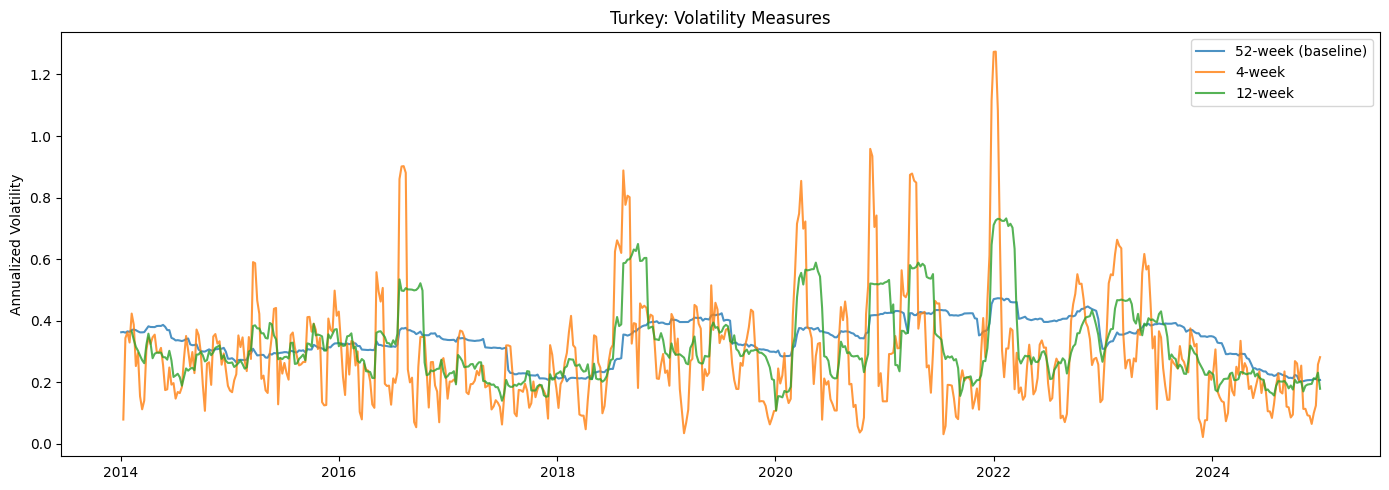

In [8]:
# Visualize vol comparison for one country
sample_country = 'Turkey'
sample = panel[panel['country'] == sample_country].copy()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample['date'], sample['msci_vol_52w'], label='52-week (baseline)', alpha=0.8)
ax.plot(sample['date'], sample['vol_4w'], label='4-week', alpha=0.8)
ax.plot(sample['date'], sample['vol_12w'], label='12-week', alpha=0.8)
ax.set_ylabel('Annualized Volatility')
ax.set_title(f'{sample_country}: Volatility Measures')
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Scale Assets (Same as Baseline)

In [9]:
# Scale asset value
scale_factors = panel.groupby('country').apply(
    lambda g: TARGET_RATIO * g['default_barrier'].mean() / g['msci_index'].mean()
).reset_index()
scale_factors.columns = ['country', 'scale_factor']

panel = panel.merge(scale_factors, on='country')
panel['A'] = panel['msci_index'] * panel['scale_factor']

---
## 4. Compute d₂ and PD for Each Volatility Specification

In [10]:
def compute_d2(A, B, sigma, r, T=1.0):
    """Merton distance-to-default."""
    with np.errstate(divide='ignore', invalid='ignore'):
        d2 = (np.log(A / B) + (r - sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    return d2

def compute_pd(d2):
    """Risk-neutral default probability."""
    return norm.cdf(-d2)

In [11]:
# Baseline (52-week vol)
panel['d2_baseline'] = compute_d2(panel['A'], panel['default_barrier'], 
                                   panel['msci_vol_52w'], panel['rf'], T)
panel['pd_baseline'] = compute_pd(panel['d2_baseline'])

# Short-term vol versions
for w in VOL_WINDOWS:
    vol_col = f'vol_{w}w'
    panel[f'd2_{w}w'] = compute_d2(panel['A'], panel['default_barrier'], 
                                    panel[vol_col], panel['rf'], T)
    panel[f'pd_{w}w'] = compute_pd(panel[f'd2_{w}w'])

print("PD summary by volatility window:")
pd_cols = ['pd_baseline'] + [f'pd_{w}w' for w in VOL_WINDOWS]
print(panel[pd_cols].describe().round(3))

PD summary by volatility window:
       pd_baseline      pd_4w      pd_8w     pd_12w     pd_26w
count    10961.000  10941.000  10901.000  10861.000  10721.000
mean         0.277      0.244      0.255      0.261      0.271
std          0.244      0.263      0.255      0.253      0.249
min          0.000      0.000      0.000      0.000      0.000
25%          0.054      0.012      0.028      0.036      0.044
50%          0.217      0.143      0.176      0.184      0.201
75%          0.449      0.417      0.427      0.437      0.451
max          0.956      1.000      0.995      0.966      0.944


---
## 5. Compute Changes for Regression

In [12]:
panel = panel.sort_values(['country', 'date'])

# Δln(CDS)
panel['ln_cds'] = np.log(panel['cds_spread'])
panel['d_ln_cds'] = panel.groupby('country')['ln_cds'].diff()

# ΔPD for each specification
panel['d_pd_baseline'] = panel.groupby('country')['pd_baseline'].diff()
for w in VOL_WINDOWS:
    panel[f'd_pd_{w}w'] = panel.groupby('country')[f'pd_{w}w'].diff()

# Time FE
panel['ym'] = panel['date'].dt.to_period('M').astype(str)

# Clean data
reg_cols = ['d_ln_cds', 'd_pd_baseline'] + [f'd_pd_{w}w' for w in VOL_WINDOWS]
reg_data = panel.dropna(subset=reg_cols)
reg_data = reg_data.replace([np.inf, -np.inf], np.nan).dropna(subset=reg_cols)

print(f"Regression sample: {len(reg_data)} obs, {reg_data['country'].nunique()} countries")

Regression sample: 10701 obs, 20 countries


---
## 6. Compare All Specifications: Full Sample

In [13]:
# Run regression for each specification
results = []

# Baseline
m = smf.ols('d_ln_cds ~ d_pd_baseline + C(country) + C(ym)', data=reg_data).fit()
results.append({
    'model': 'Baseline (52w)',
    'vol_window': 52,
    'beta': m.params['d_pd_baseline'],
    't_stat': m.tvalues['d_pd_baseline'],
    'r_squared': m.rsquared,
    'n_obs': int(m.nobs)
})

# Short-term vol versions
for w in VOL_WINDOWS:
    m = smf.ols(f'd_ln_cds ~ d_pd_{w}w + C(country) + C(ym)', data=reg_data).fit()
    results.append({
        'model': f'{w}-week vol',
        'vol_window': w,
        'beta': m.params[f'd_pd_{w}w'],
        't_stat': m.tvalues[f'd_pd_{w}w'],
        'r_squared': m.rsquared,
        'n_obs': int(m.nobs)
    })

results_df = pd.DataFrame(results)

print("="*70)
print("MODEL COMPARISON: FULL SAMPLE")
print("="*70)
print(results_df.to_string(index=False))

MODEL COMPARISON: FULL SAMPLE
         model  vol_window     beta    t_stat  r_squared  n_obs
Baseline (52w)          52 0.701776 26.047790   0.139718  10701
    4-week vol           4 0.077474  9.445946   0.092080  10701
    8-week vol           8 0.194894 13.376772   0.099670  10701
   12-week vol          12 0.338770 18.459505   0.113045  10701
   26-week vol          26 0.573839 24.136266   0.132306  10701


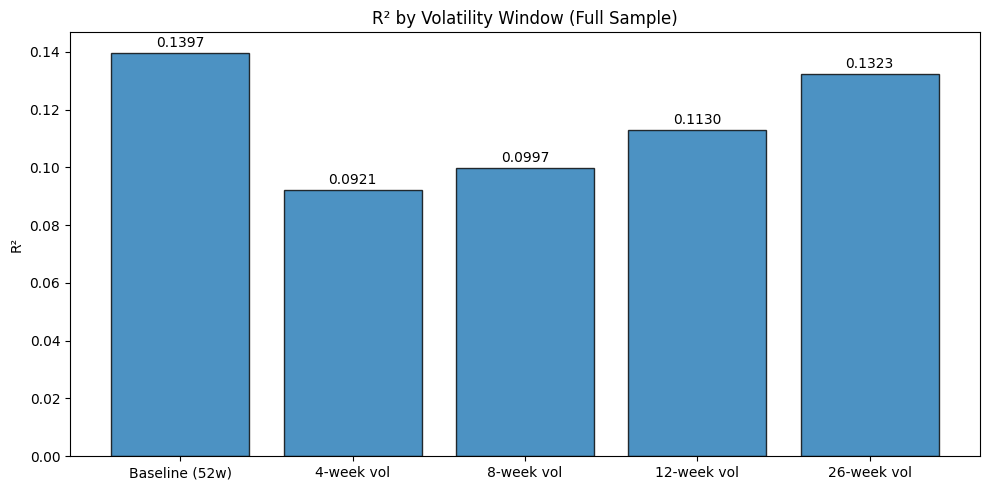

In [14]:
# Visualize R² by volatility window
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(results_df['model'], results_df['r_squared'], alpha=0.8, edgecolor='black')
ax.set_ylabel('R²')
ax.set_title('R² by Volatility Window (Full Sample)')

# Add value labels
for i, (model, r2) in enumerate(zip(results_df['model'], results_df['r_squared'])):
    ax.text(i, r2 + 0.002, f'{r2:.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

---
## 7. Compare by Group: Oil Exporters vs Controls

In [15]:
# Best short-term model (pick lowest window with improvement, or just use 4w)
BEST_SHORT_VOL = 4  # 4-week

# Split samples
oil_sample = reg_data[reg_data['group'] == 'oil_exporter']
control_sample = reg_data[reg_data['group'] == 'control']

print(f"Oil exporters: {oil_sample['country'].nunique()} countries, {len(oil_sample)} obs")
print(f"Controls: {control_sample['country'].nunique()} countries, {len(control_sample)} obs")

Oil exporters: 6 countries, 3054 obs
Controls: 8 countries, 4345 obs


In [16]:
# Run regressions by group for baseline and best short-term
group_results = []

for group_name, sample in [('Oil Exporters', oil_sample), ('Controls', control_sample)]:
    # Baseline
    m1 = smf.ols('d_ln_cds ~ d_pd_baseline + C(country) + C(ym)', data=sample).fit()
    
    # Short-term
    m2 = smf.ols(f'd_ln_cds ~ d_pd_{BEST_SHORT_VOL}w + C(country) + C(ym)', data=sample).fit()
    
    group_results.append({
        'group': group_name,
        'beta_baseline': m1.params['d_pd_baseline'],
        'r2_baseline': m1.rsquared,
        'beta_short': m2.params[f'd_pd_{BEST_SHORT_VOL}w'],
        'r2_short': m2.rsquared,
        'r2_improvement': m2.rsquared - m1.rsquared,
        'r2_pct_change': (m2.rsquared / m1.rsquared - 1) * 100,
        'n_obs': int(m1.nobs)
    })

group_df = pd.DataFrame(group_results)

print("="*80)
print(f"COMPARISON: BASELINE vs {BEST_SHORT_VOL}-WEEK VOL BY GROUP")
print("="*80)
print(group_df.to_string(index=False))

COMPARISON: BASELINE vs 4-WEEK VOL BY GROUP
        group  beta_baseline  r2_baseline  beta_short  r2_short  r2_improvement  r2_pct_change  n_obs
Oil Exporters       0.696689     0.209693    0.108046  0.158167       -0.051527     -24.572423   3054
     Controls       0.874210     0.237574    0.100585  0.156506       -0.081068     -34.123261   4345


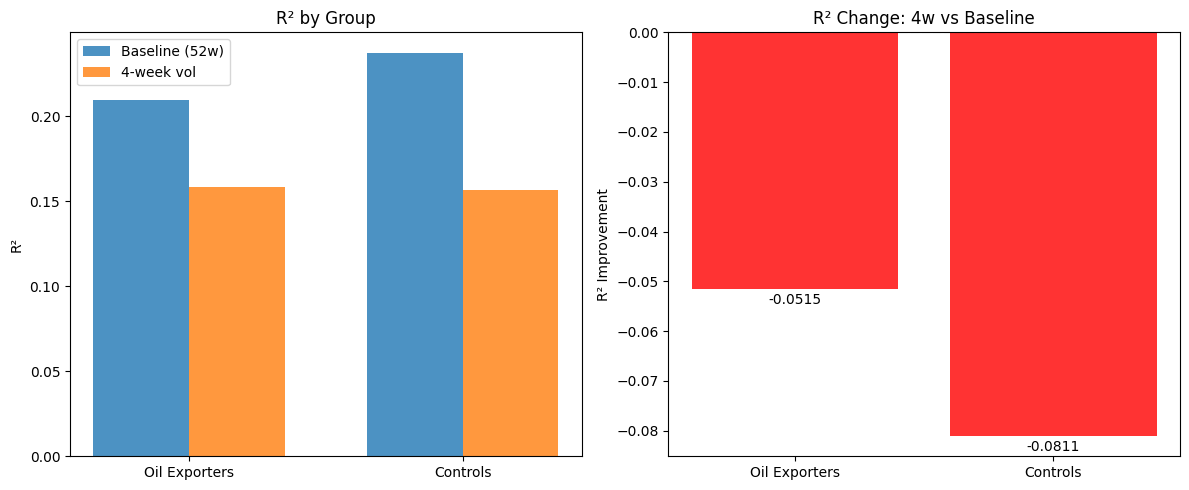

In [17]:
# Visualize group comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# R² comparison
ax = axes[0]
x = np.arange(len(group_df))
width = 0.35
ax.bar(x - width/2, group_df['r2_baseline'], width, label='Baseline (52w)', alpha=0.8)
ax.bar(x + width/2, group_df['r2_short'], width, label=f'{BEST_SHORT_VOL}-week vol', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(group_df['group'])
ax.set_ylabel('R²')
ax.set_title('R² by Group')
ax.legend()

# R² improvement
ax = axes[1]
colors = ['green' if x > 0 else 'red' for x in group_df['r2_improvement']]
ax.bar(group_df['group'], group_df['r2_improvement'], color=colors, alpha=0.8)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_ylabel('R² Improvement')
ax.set_title(f'R² Change: {BEST_SHORT_VOL}w vs Baseline')

# Add value labels
for i, val in enumerate(group_df['r2_improvement']):
    ax.text(i, val + 0.001 if val > 0 else val - 0.003, f'{val:.4f}', ha='center')

plt.tight_layout()
plt.show()

---
## 8. Country-Level Comparison

In [18]:
# R² by country for baseline vs short-term
country_results = []

for country in reg_data['country'].unique():
    df = reg_data[reg_data['country'] == country]
    if len(df) < 50:
        continue
    
    # Baseline
    s1, _, r1, _, _ = linregress(df['d_pd_baseline'].fillna(0), df['d_ln_cds'].fillna(0))
    
    # Short-term
    s2, _, r2, _, _ = linregress(df[f'd_pd_{BEST_SHORT_VOL}w'].fillna(0), df['d_ln_cds'].fillna(0))
    
    country_results.append({
        'country': country,
        'group': df['group'].iloc[0],
        'r2_baseline': r1**2,
        'r2_short': r2**2,
        'r2_improvement': r2**2 - r1**2
    })

country_df = pd.DataFrame(country_results).sort_values('r2_improvement', ascending=False)

print("Country-level R² comparison:")
print(country_df.to_string(index=False))

Country-level R² comparison:
     country        group  r2_baseline  r2_short  r2_improvement
Saudi Arabia oil_exporter     0.061076  0.072177        0.011101
       Egypt oil_exporter     0.000344  0.000801        0.000457
       India        other     0.000117  0.000413        0.000296
       China      control     0.004949  0.002013       -0.002935
     Czechia        other     0.017660  0.012234       -0.005426
      Greece        other     0.011224  0.000502       -0.010722
      Poland        other     0.053198  0.008862       -0.044336
 Philippines      control     0.072412  0.026383       -0.046029
       Chile      control     0.078532  0.022731       -0.055801
    Thailand      control     0.082452  0.015913       -0.066539
    Malaysia oil_exporter     0.152423  0.053425       -0.098998
     Hungary        other     0.129431  0.018592       -0.110839
 South Korea      control     0.168292  0.010121       -0.158171
        Peru        other     0.182632  0.020847       -0.161

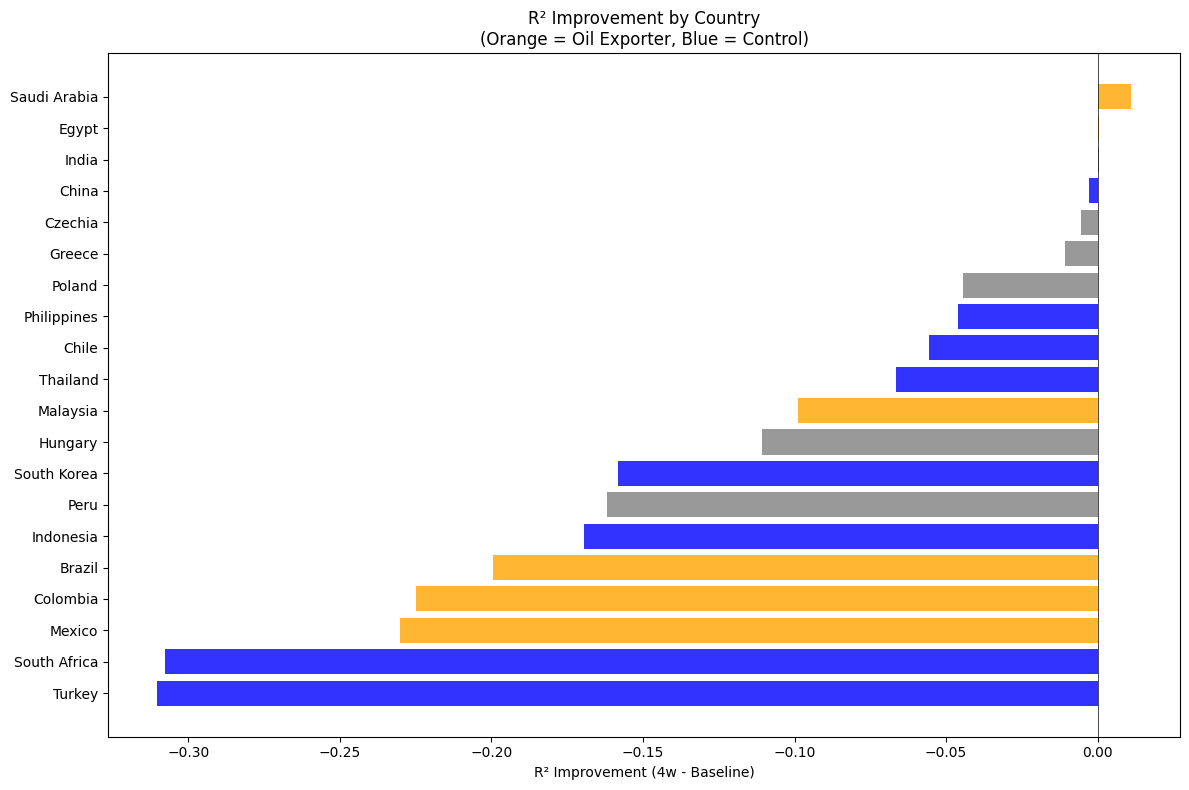

In [19]:
# Plot R² improvement by country
fig, ax = plt.subplots(figsize=(12, 8))

country_df_sorted = country_df.sort_values('r2_improvement', ascending=True)
colors = ['orange' if g == 'oil_exporter' else ('blue' if g == 'control' else 'gray') 
          for g in country_df_sorted['group']]

ax.barh(country_df_sorted['country'], country_df_sorted['r2_improvement'], 
        color=colors, alpha=0.8)
ax.axvline(0, color='k', linestyle='-', linewidth=0.5)
ax.set_xlabel(f'R² Improvement ({BEST_SHORT_VOL}w - Baseline)')
ax.set_title('R² Improvement by Country\n(Orange = Oil Exporter, Blue = Control)')

plt.tight_layout()
plt.show()

---
## 9. Time Series Comparison

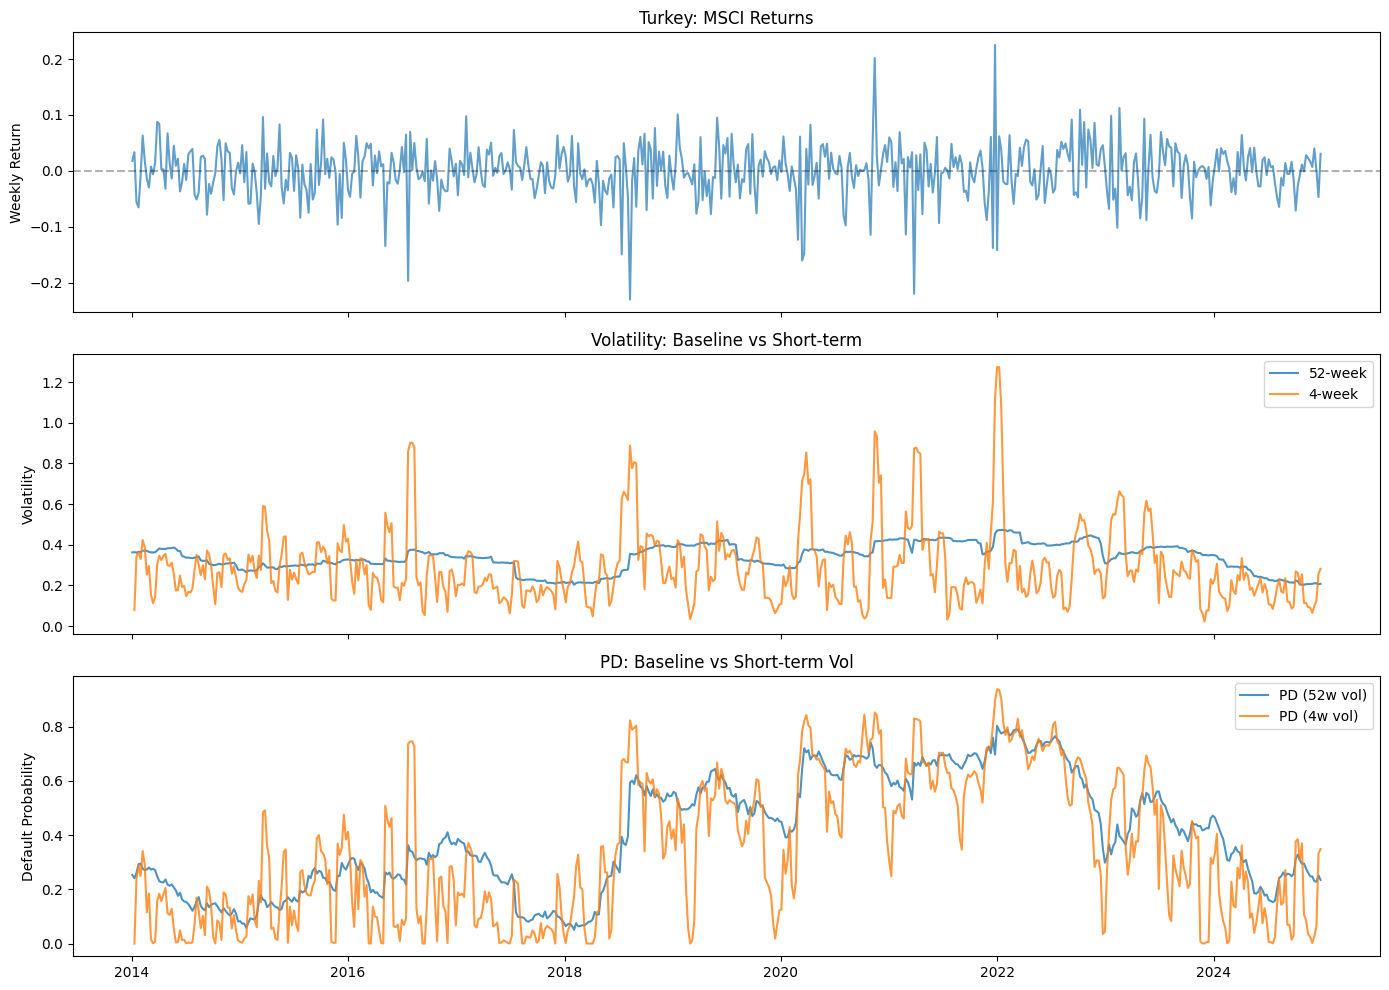

In [20]:
# Compare PD dynamics during stress periods
sample_country = 'Turkey'
sample = panel[panel['country'] == sample_country].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# MSCI returns
ax = axes[0]
ax.plot(sample['date'], sample['msci_ret_weekly'], alpha=0.7)
ax.axhline(0, color='k', linestyle='--', alpha=0.3)
ax.set_ylabel('Weekly Return')
ax.set_title(f'{sample_country}: MSCI Returns')

# Volatility comparison
ax = axes[1]
ax.plot(sample['date'], sample['msci_vol_52w'], label='52-week', alpha=0.8)
ax.plot(sample['date'], sample[f'vol_{BEST_SHORT_VOL}w'], label=f'{BEST_SHORT_VOL}-week', alpha=0.8)
ax.set_ylabel('Volatility')
ax.set_title('Volatility: Baseline vs Short-term')
ax.legend()

# PD comparison
ax = axes[2]
ax.plot(sample['date'], sample['pd_baseline'], label='PD (52w vol)', alpha=0.8)
ax.plot(sample['date'], sample[f'pd_{BEST_SHORT_VOL}w'], label=f'PD ({BEST_SHORT_VOL}w vol)', alpha=0.8)
ax.set_ylabel('Default Probability')
ax.set_title('PD: Baseline vs Short-term Vol')
ax.legend()

plt.tight_layout()
plt.show()

---
## 10. Summary

In [21]:
print("\n" + "="*70)
print("MODEL 2: TIME-VARYING VOLATILITY — SUMMARY")
print("="*70)

print("\n1. MODEL SPECIFICATIONS TESTED")
print(results_df[['model', 'r_squared']].to_string(index=False))

# Find best
best_model = results_df.loc[results_df['r_squared'].idxmax()]
baseline = results_df[results_df['vol_window'] == 52].iloc[0]

print(f"\n2. BEST MODEL: {best_model['model']}")
print(f"   R²: {best_model['r_squared']:.4f} vs baseline {baseline['r_squared']:.4f}")
print(f"   Improvement: {best_model['r_squared'] - baseline['r_squared']:.4f}")

print("\n3. BY GROUP")
for _, row in group_df.iterrows():
    print(f"   {row['group']}: baseline R²={row['r2_baseline']:.4f}, "
          f"short R²={row['r2_short']:.4f}, Δ={row['r2_improvement']:.4f}")

print("\n4. INTERPRETATION")
if best_model['r_squared'] > baseline['r_squared']:
    print(f"   - Short-term vol ({best_model['model']}) improves over baseline")
    print(f"   - Model captures stress periods better")
else:
    print(f"   - Baseline (52w) performs as well or better")
    print(f"   - Smoothed vol sufficient for weekly CDS dynamics")


MODEL 2: TIME-VARYING VOLATILITY — SUMMARY

1. MODEL SPECIFICATIONS TESTED
         model  r_squared
Baseline (52w)   0.139718
    4-week vol   0.092080
    8-week vol   0.099670
   12-week vol   0.113045
   26-week vol   0.132306

2. BEST MODEL: Baseline (52w)
   R²: 0.1397 vs baseline 0.1397
   Improvement: 0.0000

3. BY GROUP
   Oil Exporters: baseline R²=0.2097, short R²=0.1582, Δ=-0.0515
   Controls: baseline R²=0.2376, short R²=0.1565, Δ=-0.0811

4. INTERPRETATION
   - Baseline (52w) performs as well or better
   - Smoothed vol sufficient for weekly CDS dynamics


---
## 11. Save Results

In [ ]:
# Save comparison metrics
results_df.to_csv('data/processed/model2_vol_comparison.csv', index=False)
group_df.to_csv('data/processed/model2_group_results.csv', index=False)
country_df.to_csv('data/processed/model2_country_results.csv', index=False)

print("Saved:")
print("  - model2_vol_comparison.csv")
print("  - model2_group_results.csv")
print("  - model2_country_results.csv")

In [ ]:
# Key metrics for final comparison
model2_metrics = {
    'model': f'Time-Varying Vol ({BEST_SHORT_VOL}w)',
    'beta_full': results_df[results_df['vol_window']==BEST_SHORT_VOL]['beta'].values[0],
    'r2_full': results_df[results_df['vol_window']==BEST_SHORT_VOL]['r_squared'].values[0],
    'r2_oil': group_df[group_df['group']=='Oil Exporters']['r2_short'].values[0],
    'r2_control': group_df[group_df['group']=='Controls']['r2_short'].values[0],
}

pd.DataFrame([model2_metrics]).to_csv('data/processed/model2_metrics.csv', index=False)
print("\nKey metrics:")
print(pd.DataFrame([model2_metrics]).T)